# 3 - Classical baseline: Lasso


> Part of **[Compressed Sensing using Generative Models](../README.md)**.
> Run `pip install -e .` from the repository root first; every notebook imports
> the `csgm` package rather than redefining the model and recovery code inline.


Before measuring what a learned prior buys us, we need the classical reference.
Standard compressed sensing assumes the signal is **sparse in a fixed basis**:
$x = \Psi \theta$ with only $k \ll n$ non-zero coefficients. Recovery is then a
convex program,

$$\hat\theta = \arg\min_\theta \; \|A \Psi \theta - y\|_2^2 + \alpha \|\theta\|_1,
\qquad \hat x = \Psi \hat\theta,$$

solved here with coordinate descent.

Two choices of $\Psi$ matter here. The **pixel basis**, $\Psi = I$, is the one
Bora et al. use on MNIST: a digit is mostly background, so it is already sparse
in pixel space. The **orthonormal DCT**, the basis JPEG relies on, is what the
same authors use for natural images. They behave very differently on this
dataset, so both are reported.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from csgm.baselines import dct_basis, lasso_recover
from csgm.config import DEFAULT_SEED, N_PIXELS
from csgm.data import load_mnist
from csgm.measurements import gaussian_measurement_matrix, measure
from csgm.metrics import per_pixel_l2, psnr
from csgm.viz import plot_error_curves, show_images

## 3.1 How sparse is MNIST in the DCT basis?

The premise is worth checking rather than assuming. Below we keep only the
largest DCT coefficients of a digit and discard the rest.

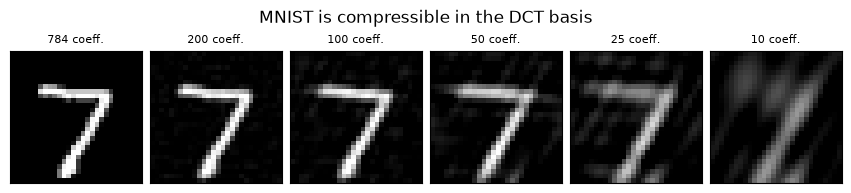

In [2]:
(_, _), (x_test, y_test) = load_mnist(flatten=True)
x_star = x_test[0]

psi = dct_basis(N_PIXELS)
theta = psi.T @ x_star            # analysis: Psi is orthonormal, so Psi^T inverts it

kept = [784, 200, 100, 50, 25, 10]
approximations = []
for k in kept:
    truncated = np.zeros_like(theta)
    idx = np.argsort(np.abs(theta))[-k:]
    truncated[idx] = theta[idx]
    approximations.append(np.clip(psi @ truncated, 0, 1))

show_images(
    np.stack(approximations),
    [f"{k} coeff." for k in kept],
    ncols=6,
    suptitle="MNIST is compressible in the DCT basis",
);

25 coefficients out of 784 already give a recognisable digit, so the sparsity
assumption is not unreasonable. The catch is that compressed sensing does not
get to *choose* which coefficients to keep - it has to discover their support
from random projections, and that is what costs measurements.

## 3.2 Recovery as a function of the measurement budget

Entries of $A$ are drawn i.i.d. from $\mathcal{N}(0, 1/m)$, which makes $A$ an
approximate isometry in expectation, and the noise is scaled so that its expected norm stays at 0.1 whatever the
budget, which is the convention of the reference paper and of the benchmark.

In [3]:
m_values = [25, 50, 100, 200, 300, 400, 500, 750]
reconstructions, errors = [], {"pixel": [], "dct": []}

for m in m_values:
    A = gaussian_measurement_matrix(m, N_PIXELS, seed=DEFAULT_SEED + m)
    # Keep the expected noise norm fixed at 0.1 across budgets, as in Bora et al.
    y = measure(x_star, A, noise_std=0.1 / np.sqrt(m), seed=DEFAULT_SEED + m)
    for basis in ("pixel", "dct"):
        x_hat = lasso_recover(y, A, basis=basis, alpha=1e-5)[0]
        errors[basis].append(per_pixel_l2(x_hat, x_star)[0])
        if basis == "dct":
            reconstructions.append(x_hat)
    print(f"m = {m:>3} | pixel {errors['pixel'][-1]:.4f} | dct {errors['dct'][-1]:.4f}")

m =  25 | pixel 0.0791 | dct 0.0679


m =  50 | pixel 0.0759 | dct 0.0646


m = 100 | pixel 0.0628 | dct 0.0480


m = 200 | pixel 0.0355 | dct 0.0267


m = 300 | pixel 0.0007 | dct 0.0222
m = 400 | pixel 0.0000 | dct 0.0094


m = 500 | pixel 0.0000 | dct 0.0034
m = 750 | pixel 0.0000 | dct 0.0012


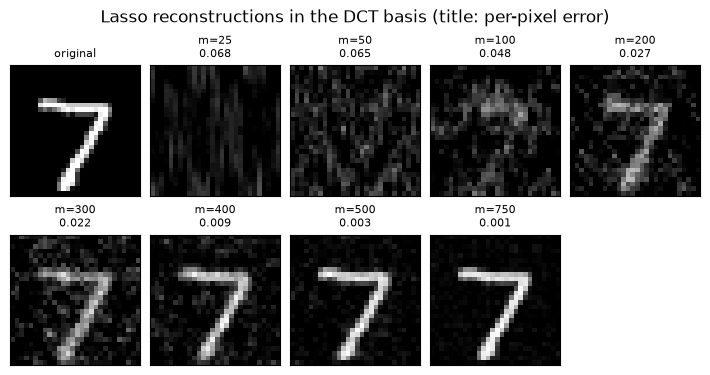

In [4]:
show_images(
    np.stack([x_star, *reconstructions]),
    ["original", *[f"m={m}\n{e:.3f}" for m, e in zip(m_values, errors["dct"])]],
    ncols=5,
    suptitle="Lasso reconstructions in the DCT basis (title: per-pixel error)",
);

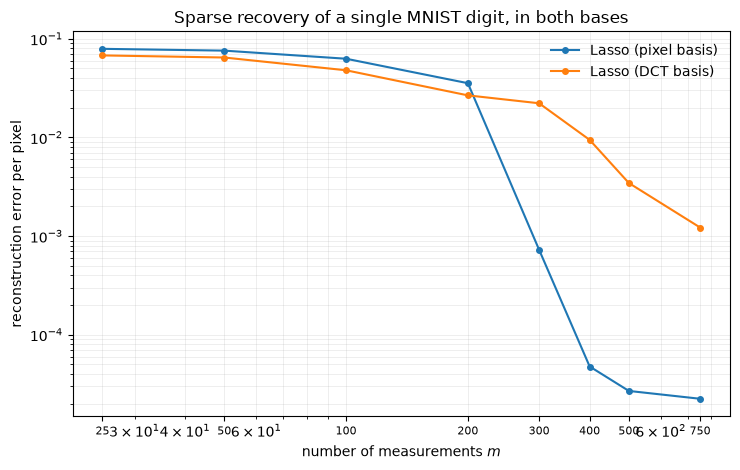

In [5]:
plot_error_curves(
    {
        "Lasso (pixel basis)": (m_values, errors["pixel"]),
        "Lasso (DCT basis)": (m_values, errors["dct"]),
    },
    logx=True,
    title="Sparse recovery of a single MNIST digit, in both bases",
);

## 3.3 Reading the baseline

The two bases cross over. Below a few hundred measurements the DCT is the
stronger of the two, because a handful of low-frequency coefficients already
sketch a digit. Once the budget approaches the 784 dimensions of the signal the
pixel basis wins outright, since an MNIST digit really is sparse there and the
support becomes identifiable.

Two things stand out about both, and they motivate the rest of the project:

1. **Below ~100 measurements the reconstruction is unusable.** The digit is
   buried in background speckle: with so few random projections the $\ell_1$
   program cannot pin down which DCT coefficients are active.
2. **Even at high $m$ the background stays noisy.** Sparsity says nothing about
   *which* patterns are plausible, so nothing prevents the solver from spending
   coefficients on structure no digit ever has.

A generative prior replaces "few non-zero coefficients" with "looks like a
digit", a far stronger statement - and one that a network can learn from data
instead of us having to design a basis.

---
Next: [4 - Compressed sensing with generative models](04_compressed_sensing_recovery.ipynb).